# Historical Shocks: Log Returns vs Absolute Dollar Changes

**Purpose:** Demonstrate the difference between three historical simulation approaches:
1. Direct portfolio log-return shocks
2. Component log-return reconstruction (does NOT equal the direct portfolio shock)
3. Absolute dollar-change reconstruction (equals direct portfolio dollar shock exactly)

This distinction is critical for correct historical simulation.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PURCHASE_DATE = '10/13/1997'
SHARES_AAPL   = 24679
SHARES_CAT    = 171
HORIZON       = 5
LOOKBACK      = 2 * 252
VAR_CONF      = 0.99
ES_CONF       = 0.975
print('Imports OK')

Imports OK


## Section 1 — Load Data

In [2]:
aapl_px = pd.read_csv('../data/AAPL-bloomberg.csv', parse_dates=['Dates'], dayfirst=False)
aapl_px = aapl_px.set_index('Dates').sort_index()['PX_LAST']

cat_px = pd.read_csv('../data/CAT-bloomberg.csv', parse_dates=['Dates'], dayfirst=False)
cat_px = cat_px.set_index('Dates').sort_index()['PX_LAST']

prices = pd.DataFrame({'AAPL': aapl_px, 'CAT': cat_px}).dropna()
prices = prices[prices.index >= pd.Timestamp(PURCHASE_DATE)]

port_val = SHARES_AAPL * prices['AAPL'] + SHARES_CAT * prices['CAT']
print(f'Rows: {len(prices)}, last date: {prices.index[-1].date()}')
print(f'Portfolio value (last): ${port_val.iloc[-1]:,.2f}')

Rows: 7127, last date: 2026-02-11
Portfolio value (last): $6,931,589.50


## Section 2 — Direct Portfolio Log-Return Scenarios

In [3]:
# Overlapping h-day log-returns on portfolio value directly
log_port = np.log(port_val / port_val.shift(1)).dropna()

# Build overlapping h-day log-returns: R_t = sum of h daily log-returns
# R_t^{(h)} = log(port_t / port_{t-h})
port_h_log = np.log(port_val / port_val.shift(HORIZON)).dropna()
port_h_log_window = port_h_log.tail(LOOKBACK)

# Losses = -1 * log-return * V0 (first-order approximation)
V0 = port_val.iloc[-1]
log_losses_direct = -port_h_log_window.values * V0

direct_var = float(np.quantile(log_losses_direct, VAR_CONF))
direct_es  = float(np.mean(log_losses_direct[log_losses_direct >= np.quantile(log_losses_direct, ES_CONF)]))
print(f'Direct log-return VaR 99%:  ${direct_var:,.2f}')
print(f'Direct log-return ES  97.5%: ${direct_es:,.2f}')
print(f'Scenarios: {len(log_losses_direct)}')

Direct log-return VaR 99%:  $775,250.86
Direct log-return ES  97.5%: $799,872.73
Scenarios: 504


## Section 3 — Component Log-Return Reconstruction

Build 5-day shocks on AAPL and CAT separately, then reconstruct the portfolio P&L as:
$$\Delta P = n_{AAPL}(S_{AAPL} e^{R_{AAPL}} - S_{AAPL}) + n_{CAT}(S_{CAT} e^{R_{CAT}} - S_{CAT})$$
This does **not** equal the direct portfolio log-return loss in general, because:
$$\log\bigl(n_A S_A e^{R_A} + n_C S_C e^{R_C}\bigr) \neq n_A S_A R_A + n_C S_C R_C$$

In [4]:
# Component h-day log-returns (overlapping)
aapl_h_log = np.log(prices['AAPL'] / prices['AAPL'].shift(HORIZON)).dropna()
cat_h_log  = np.log(prices['CAT']  / prices['CAT'].shift(HORIZON)).dropna()

# Align on common index
comp_log = pd.DataFrame({'AAPL': aapl_h_log, 'CAT': cat_h_log}).dropna()
comp_log_window = comp_log.tail(LOOKBACK)

S_aapl = prices['AAPL'].iloc[-1]
S_cat  = prices['CAT'].iloc[-1]

# Reconstruct portfolio P&L via component GBM shocks
comp_losses = -(SHARES_AAPL * S_aapl * (np.exp(comp_log_window['AAPL'].values) - 1)
              + SHARES_CAT  * S_cat  * (np.exp(comp_log_window['CAT'].values)  - 1))

comp_var = float(np.quantile(comp_losses, VAR_CONF))
comp_es  = float(np.mean(comp_losses[comp_losses >= np.quantile(comp_losses, ES_CONF)]))
print(f'Component log-return VaR 99%:  ${comp_var:,.2f}')
print(f'Component log-return ES  97.5%: ${comp_es:,.2f}')
print(f'Discrepancy vs direct VaR: ${comp_var - direct_var:,.2f}')

Component log-return VaR 99%:  $728,791.66
Component log-return ES  97.5%: $742,986.34
Discrepancy vs direct VaR: $-46,459.21


## Section 4 — Absolute Dollar-Change Reconstruction

Build 5-day overlapping dollar changes: $\delta S_t = S_t - S_{t-5}$.
Portfolio dollar change: $\Delta P = n_{AAPL}\,\delta S_{AAPL} + n_{CAT}\,\delta S_{CAT}$.

This **exactly** equals the direct portfolio dollar change, to machine precision.

In [5]:
# Component h-day absolute dollar changes
aapl_h_abs = prices['AAPL'] - prices['AAPL'].shift(HORIZON)
cat_h_abs  = prices['CAT']  - prices['CAT'].shift(HORIZON)

# Direct portfolio dollar change
port_h_abs = port_val - port_val.shift(HORIZON)

# Reconstructed from components
port_h_reconstructed = SHARES_AAPL * aapl_h_abs + SHARES_CAT * cat_h_abs

# Align and compare
comp_abs = pd.DataFrame({
    'direct':       port_h_abs,
    'reconstructed': port_h_reconstructed,
}).dropna()
diff = (comp_abs['direct'] - comp_abs['reconstructed']).abs()
print(f'Max absolute difference (direct vs reconstructed): {diff.max():.2e}')
print('This should be essentially zero (machine precision).')

# VaR/ES from absolute losses
abs_losses = -comp_abs['direct'].tail(LOOKBACK).values
abs_var = float(np.quantile(abs_losses, VAR_CONF))
abs_es  = float(np.mean(abs_losses[abs_losses >= np.quantile(abs_losses, ES_CONF)]))
print(f'\nAbsolute Dollar VaR 99%:  ${abs_var:,.2f}')
print(f'Absolute Dollar ES  97.5%: ${abs_es:,.2f}')

Max absolute difference (direct vs reconstructed): 1.70e-09
This should be essentially zero (machine precision).

Absolute Dollar VaR 99%:  $620,472.93
Absolute Dollar ES  97.5%: $601,686.22


## Section 5 — historical_var_es with shock_type='log' vs 'absolute'

In [6]:
from src.risk.historical import historical_var_es
from src.schemas import Portfolio, StockPosition

portfolio_obj = Portfolio(stocks=[
    StockPosition(ticker='AAPL', quantity=SHARES_AAPL),
    StockPosition(ticker='CAT',  quantity=SHARES_CAT),
])
pricing_dt = prices.index[-1].date()

res_log = historical_var_es(
    portfolio_obj, prices, pricing_dt, LOOKBACK, HORIZON, VAR_CONF, ES_CONF, shock_type='log')
res_abs = historical_var_es(
    portfolio_obj, prices, pricing_dt, LOOKBACK, HORIZON, VAR_CONF, ES_CONF, shock_type='absolute')

print(f"{'Method':<25} {'VaR 99%':>12} {'ES 97.5%':>12}")
print('-' * 51)
print(f"{'Log-return shocks':<25} {res_log['var']:>12,.0f} {res_log['es']:>12,.0f}")
print(f"{'Absolute-dollar shocks':<25} {res_abs['var']:>12,.0f} {res_abs['es']:>12,.0f}")

Method                         VaR 99%     ES 97.5%
---------------------------------------------------
Log-return shocks              728,792      742,986
Absolute-dollar shocks         620,473      601,686


## Section 6 — Scatter Plot: Direct vs Component Log Losses

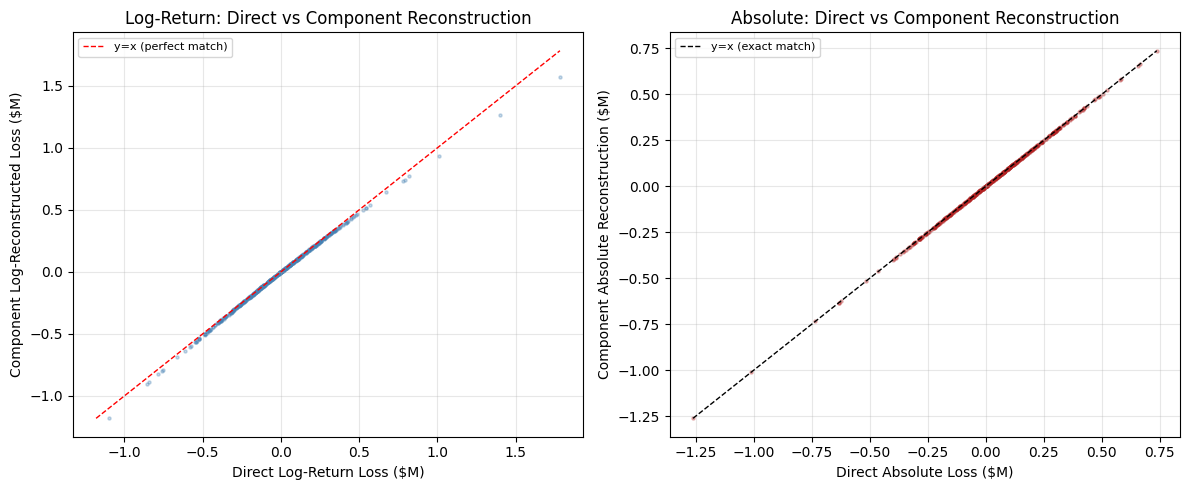

In [7]:
# Direct log-return losses vs component-reconstructed
min_n = min(len(log_losses_direct), len(comp_losses))
direct_aligned = log_losses_direct[-min_n:]
comp_aligned   = comp_losses[-min_n:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: log vs component
ax = axes[0]
ax.scatter(direct_aligned / 1e6, comp_aligned / 1e6, alpha=0.3, s=5, color='steelblue')
lims = [min(direct_aligned.min(), comp_aligned.min()) / 1e6,
        max(direct_aligned.max(), comp_aligned.max()) / 1e6]
ax.plot(lims, lims, 'r--', lw=1, label='y=x (perfect match)')
ax.set_xlabel('Direct Log-Return Loss ($M)')
ax.set_ylabel('Component Log-Reconstructed Loss ($M)')
ax.set_title('Log-Return: Direct vs Component Reconstruction')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Absolute: differences should be zero
abs_direct_w = comp_abs['direct'].tail(LOOKBACK).values
abs_recon_w  = comp_abs['reconstructed'].tail(LOOKBACK).values
ax2 = axes[1]
ax2.scatter(abs_direct_w / 1e6, abs_recon_w / 1e6, alpha=0.3, s=5, color='firebrick')
lims2 = [abs_direct_w.min() / 1e6, abs_direct_w.max() / 1e6]
ax2.plot(lims2, lims2, 'k--', lw=1, label='y=x (exact match)')
ax2.set_xlabel('Direct Absolute Loss ($M)')
ax2.set_ylabel('Component Absolute Reconstruction ($M)')
ax2.set_title('Absolute: Direct vs Component Reconstruction')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7 — Conclusion

**Why this matters for MATH 5320:**

| Method | Portfolio Identity? | Notes |
|--------|-------------------|-------|
| Direct portfolio log-return shocks | N/A (single series) | Standard HS approach; portfolios treated as single asset |
| Component log-return + GBM shocks | **No** | Non-linear mapping: log of sum ≠ sum of logs |
| Component absolute dollar shocks | **Yes (exact)** | Linear: sum of components = sum of portfolio changes |

**Log-return historical simulation** is the course standard (formula-sheet §11) and the industry norm. It is applied stock by stock, with the portfolio reprice step combining the individual shocked prices. The discrepancy vs. the direct log-return loss arises from the **non-linearity** of the portfolio value function in the individual stock returns.

**Absolute dollar shocks** reconstruct the portfolio exactly because the portfolio P&L is linear in the dollar changes of each constituent.